# Cylinder-wake Hopf bifurcation — the problem

Two-dimensional flow past a circular cylinder, parameterised by the Reynolds number
$Re = UD/\nu$. Below a critical value the wake is a **steady fixed point**; above it a
pair of complex-conjugate eigenvalues crosses the imaginary axis and the flow settles
onto a **limit cycle** — the von Kármán vortex street. A supercritical Hopf bifurcation.

Fit a single vector field to trajectories at scattered $Re$,

$$\dot{z} = f_\theta(z,\, Re), \qquad z \in \mathbb{R}^r$$

where $z$ are POD coefficients of the velocity perturbation **about that Reynolds
number's own steady base flow**. That choice makes $z = 0$ an exact fixed point at
*every* $Re$, so $f_\theta(0, Re) = 0$ can be enforced architecturally and the model
only has to learn how the linearisation at the origin moves with $Re$.

**The question:** does one model fitted to 17 time series internalise the transition?
Probe $J(Re) = \partial f_\theta/\partial z|_{z=0}$ on a fine $Re$ grid it never trained
on and see whether $\mathrm{Re}\,\lambda_{\max}$ crosses zero in the right place.

Measured ground truth: $\;\mathbf{Re_c = 44.2 \pm 0.3}$, $\;d\sigma/dRe = 0.0050$ (U/D per unit Re).

Nothing in the data is labelled "bifurcation". Every trajectory is just a time series.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA = Path('../data')
R = 8                                    # latent width (r = 3, 8, 16 available)

d = np.load(DATA / f'latent_r{R}.npz')
a    = d['a']                            # (n, r)  POD coordinates
adot = d['adot']                         # (n, r)  time derivative
Re   = d['Re']                           # (n,)    the parameter
traj = d['traj']                         # (n,)    trajectory id -- never window across this
t    = d['t']                            # (n,)    convective times

RE_VALS = np.unique(Re)
DT = float(np.median(np.diff(t[traj == 0])))

print(f'{len(RE_VALS)} Reynolds numbers: {RE_VALS.astype(int).tolist()}')
print(f'{len(np.unique(traj))} trajectories, {len(a):,} snapshots, r = {R}, dt = {DT:.3f} D/U')
print(f'POD energy captured at r = {R}: {100*float(d["energy"]):.1f}%')

17 Reynolds numbers: [30, 36, 41, 45, 48, 51, 54, 58, 62, 67, 73, 80, 90, 102, 118, 138, 160]
34 trajectories, 12,964 snapshots, r = 8, dt = 0.399 D/U
POD energy captured at r = 8: 95.0%


## What one Reynolds number looks like

Each $Re$ gets **two** trajectories:

- **outward** — started at the base flow plus a small kick, recording the whole spiral
  out onto the limit cycle (or the decay back to the fixed point, below onset);
- **inward** — started *outside* the limit cycle by scaling the converged periodic state
  radially, decaying onto it. Without this the model sees the vector field inside the
  cycle and never outside, so nothing pins down the cycle's stability from the far side.

Even trajectory ids are outward, odd are inward. Each run carries its own time origin, so
the red inward curve below is not a continuation of the blue — it is a separate trajectory
starting on the far side of the limit cycle.

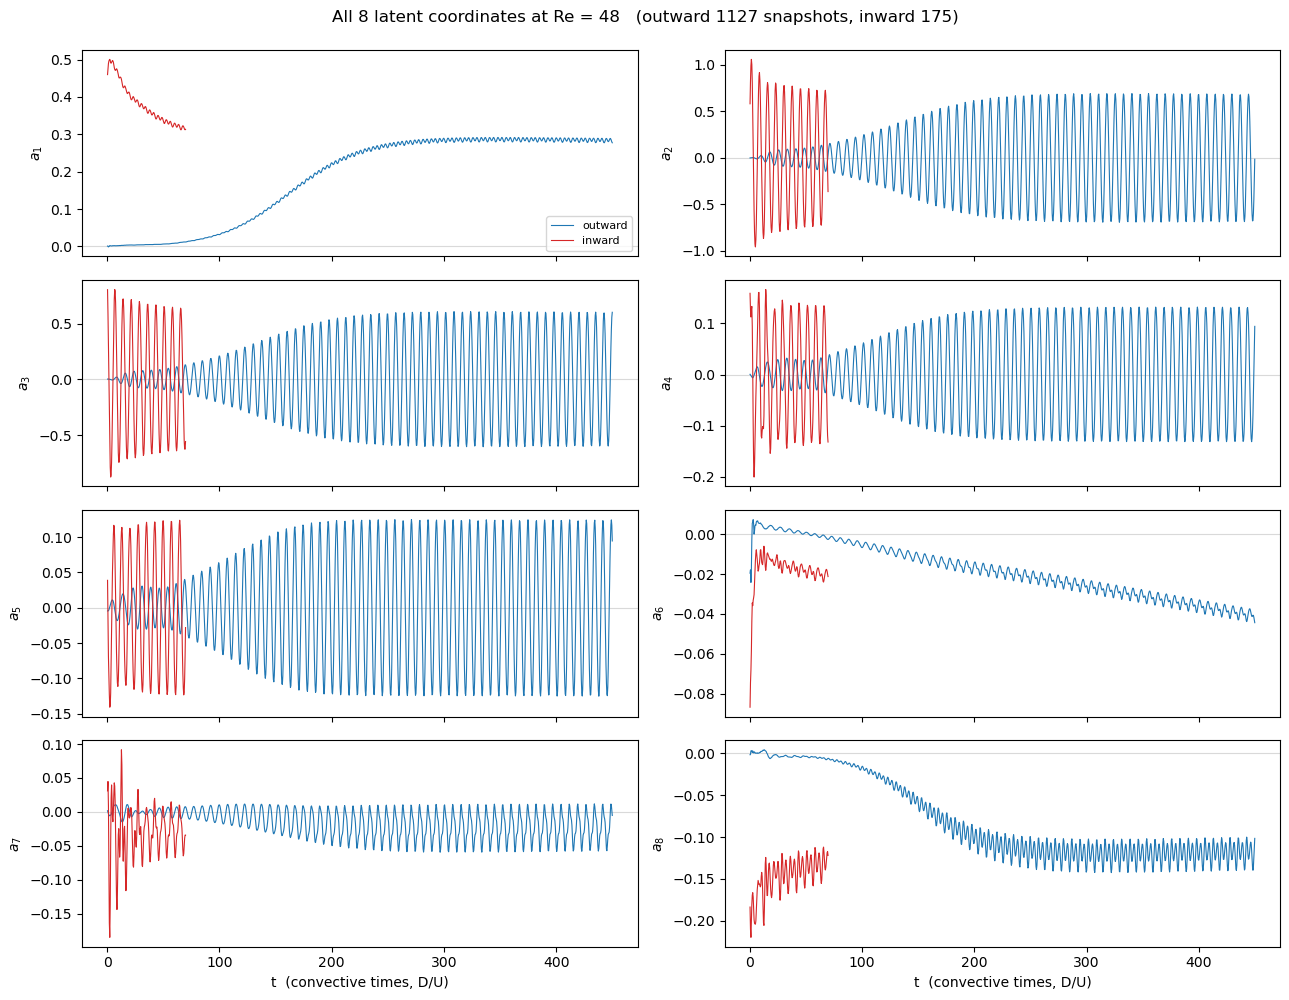

In [2]:
RE_SHOW = 48.0                           # just above onset: clean growth then saturation

j_out = int(np.unique(traj[Re == RE_SHOW])[0])
j_in  = int(np.unique(traj[Re == RE_SHOW])[1])
m_out, m_in = traj == j_out, traj == j_in

fig, axes = plt.subplots(4, 2, figsize=(13, 10), sharex=True)
for i, ax in enumerate(axes.ravel()):
    ax.plot(t[m_out], a[m_out, i], lw=0.8, color='C0', label='outward')
    ax.plot(t[m_in],  a[m_in, i],  lw=0.8, color='C3', label='inward')
    ax.set_ylabel(f'$a_{{{i+1}}}$')
    ax.axhline(0, color='0.85', lw=0.8, zorder=0)
    if i == 0:
        ax.legend(loc='lower right', fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('t  (convective times, D/U)')
fig.suptitle(f'All {R} latent coordinates at Re = {RE_SHOW:g}   '
             f'(outward {m_out.sum()} snapshots, inward {m_in.sum()})', y=0.995)
plt.tight_layout(); plt.show()

The coordinates are POD coefficients in a **single basis shared across the whole sweep**
(computed per-$Re$ and $a_3$ at $Re=60$ would be a different physical direction from
$a_3$ at $Re=150$, so $f_\theta$ would interpolate between coordinate systems rather than
between vector fields).

In this shared basis $a_1$ is the **shift mode** — the deformation of the mean flow away
from the base flow. It is not an oscillation: it ramps up and stays there, and it is what
*saturates* the instability. $a_2, a_3$ are the oscillating pair at the shedding
frequency; the rest are higher corrections and harmonics.

In [3]:
# character of each mode on the settled part of the outward run
tail = a[m_out][int(0.6 * m_out.sum()):]
freqs = np.fft.rfftfreq(len(tail), DT)

def dominant(y):
    return freqs[np.argmax(np.abs(np.fft.rfft(y - y.mean())))]

f1 = dominant(tail[:, 1])                # shedding frequency, from the oscillating pair
print(f'shedding frequency f1 = {f1:.4f} U/D  (St)\n')
print(f'{"mode":>5} {"rms":>9} {"mean":>9} {"f/f1":>7}   character')
for i in range(R):
    y = tail[:, i]
    ratio = y.std() / (abs(y.mean()) + 1e-12)
    if ratio > 3:
        kind = 'oscillatory'
    elif ratio < 1 / 3:
        kind = 'mean-carrying (shift-like)'
    else:
        kind = 'mixed'
    # a dominant frequency is only meaningful if there is an oscillation to speak of
    harm = f'{dominant(y)/f1:7.2f}' if y.std() > 0.02 * tail.std(0).max() else '     --'
    print(f'{f"a{i+1}":>5} {y.std():9.4f} {y.mean():+9.4f} {harm}   {kind}')

shedding frequency f1 = 0.1334 U/D  (St)

 mode       rms      mean    f/f1   character
   a1    0.0042   +0.2850      --   mean-carrying (shift-like)
   a2    0.4876   -0.0046    1.00   oscillatory
   a3    0.4269   +0.0055    1.00   oscillatory
   a4    0.0944   +0.0004    1.00   oscillatory
   a5    0.0884   +0.0012    1.00   oscillatory
   a6    0.0055   -0.0320      --   mean-carrying (shift-like)
   a7    0.0213   -0.0224    1.00   mixed
   a8    0.0116   -0.1199    2.04   mean-carrying (shift-like)


## The bifurcation, visible in the raw data

The oscillation amplitude $\sqrt{a_2^2 + a_3^2}$ on a log axis. Below onset it slopes
down, above onset it slopes up and then flattens onto the limit cycle. **That sign change
is the bifurcation** — onset sits between $Re = 41$ and $Re = 45$.

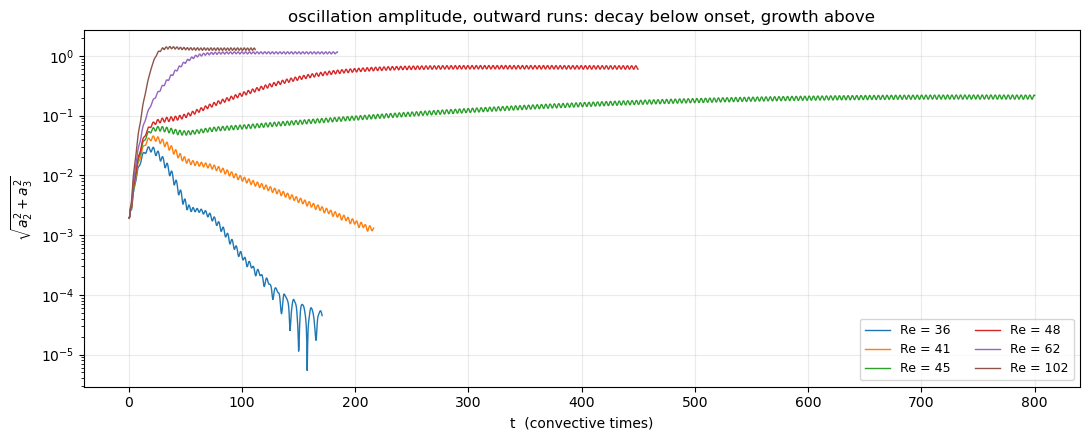

In [4]:
SHOW = [36.0, 41.0, 45.0, 48.0, 62.0, 102.0]

plt.figure(figsize=(11, 4.5))
for Rv in SHOW:
    j = int(np.unique(traj[Re == Rv])[0])              # outward run
    m = traj == j
    amp = np.hypot(a[m, 1], a[m, 2])
    plt.semilogy(t[m], amp, lw=1.0, label=f'Re = {Rv:g}')
plt.xlabel('t  (convective times)'); plt.ylabel(r'$\sqrt{a_2^2 + a_3^2}$')
plt.title('oscillation amplitude, outward runs: decay below onset, growth above')
plt.legend(ncol=2, fontsize=9); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

Two cautions this picture hides.

**The subcritical runs drift.** The stored base flows converged only to $\sim$1.5e-5
(float32 floor), so at $Re = 30, 36, 41$ the recorded perturbation contains a slow ramp
along the **non-oscillatory** directions that dominates once the oscillation has decayed.
It therefore does not show up in the amplitude above — what is visible there is $Re = 36$
hitting the float32 noise floor near $10^{-5}$. Only the first $\sim$20% of those runs is
clean ($Re = 45$: first $\sim$50%). $Re \geq 48$ is unaffected, drift being 0.1–1.8% of
signal. Truncate or drop the low-$Re$ cases.

**Do not read $Re_c$ off the saturated amplitudes.** Extrapolating $A_{sat}^2 \to 0$ is the
textbook route and it does not converge here: it returns 44.6, 44.0, 42.4, 39.2, 36.8 as
points out to $Re = 48, 54, 62, 73, 80$ are included. Any value it gives is a coordinate of
where the fit was truncated.

## How much data there is

    Re   outward   inward    total     T_out
    30       367      175      542      146
    36       428      175      603      171
    41       542      175      717      216
    45      2005      175     2180      800
    48      1127      175     1302      450
    51      1127      175     1302      450
    54       937      175     1112      374
    58       581      175      756      232
    62       462      175      637      184
    67       393      175      568      157
    73       349      175      524      139
    80       320      175      495      128
    90       296      175      471      118
   102       280      175      455      112
   118       267      175      442      107
   138       257      175      432      103
   160       251      175      426      100
                            12,964

17 parameter points x 2 trajectories = 34 trajectories
12,964 snapshots -> 12,658 multiple-shooting windows of length 10
state dimension 8 (the underlying field is 80 x 14

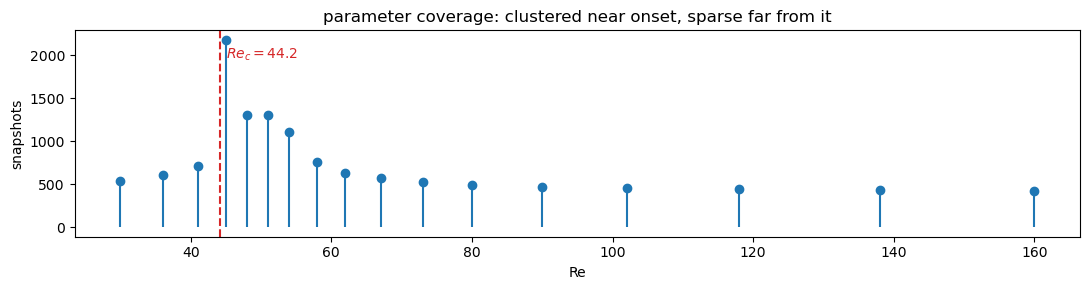

In [5]:
L = 10                                   # multiple-shooting window length, snapshots

rows, n_win = [], 0
for Rv in RE_VALS:
    ids = np.unique(traj[Re == Rv])
    n_o, n_i = (traj == ids[0]).sum(), (traj == ids[1]).sum()
    span = t[traj == ids[0]][-1]
    n_win += max(n_o - L + 1, 0) + max(n_i - L + 1, 0)
    rows.append((Rv, n_o, n_i, n_o + n_i, span))

print(f'{"Re":>6} {"outward":>9} {"inward":>8} {"total":>8} {"T_out":>9}')
for Rv, n_o, n_i, n, span in rows:
    print(f'{Rv:>6g} {n_o:>9d} {n_i:>8d} {n:>8d} {span:>8.0f}')
print(f'{"":>6} {"":>9} {"":>8} {len(a):>8,}')
print()
print(f'{len(RE_VALS)} parameter points x 2 trajectories = {len(np.unique(traj))} trajectories')
print(f'{len(a):,} snapshots -> {n_win:,} multiple-shooting windows of length {L}')
print(f'state dimension {R} (the underlying field is 80 x 140 x 2 = 22,400)')

plt.figure(figsize=(11, 3))
plt.stem(RE_VALS, [r[3] for r in rows], basefmt=' ')
plt.axvline(44.2, color='C3', ls='--', lw=1.5)
plt.text(45, 0.9 * max(r[3] for r in rows), r'$Re_c = 44.2$', color='C3')
plt.xlabel('Re'); plt.ylabel('snapshots')
plt.title('parameter coverage: clustered near onset, sparse far from it')
plt.tight_layout(); plt.show()

Run lengths are deliberately **not** uniform. The budget for each case is
$5/\sigma(Re) + 90$ convective times — five e-foldings to cross from the kick to
saturation, plus about fifteen shedding periods of settled behaviour. Because $\sigma$
vanishes at the bifurcation (critical slowing down) that formula stretches near onset and
contracts far from it: 2005 snapshots at $Re = 45$ against 251 at $Re = 160$. The sampling
interval is uniform everywhere, so the data is ragged in length only.

## The target

Growth rates measured independently from the trajectories (Landau-saturation fits, see
`scripts/growth.py`). Above $Re \approx 90$ the linear phase lasts under three shedding
periods and $\sigma$ is not resolvable.

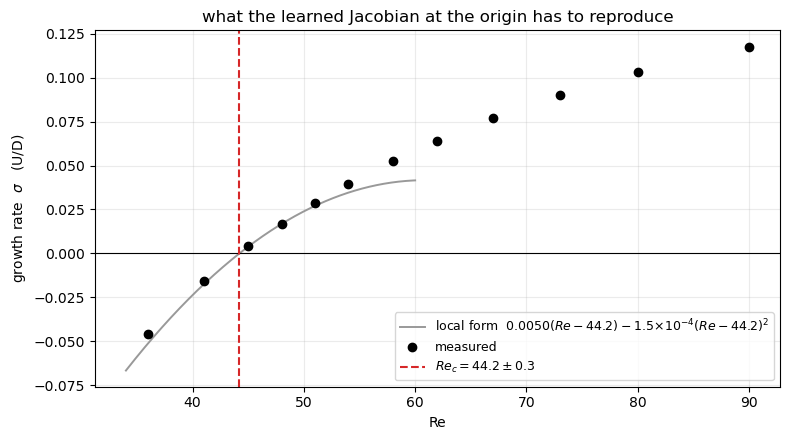

In [6]:
MEASURED = {36: -0.0460, 41: -0.0158, 45: 0.0040, 48: 0.0170, 51: 0.0286, 54: 0.0393,
            58: 0.0523, 62: 0.0639, 67: 0.0769, 73: 0.0903, 80: 0.1031, 90: 0.1177}
RE_C, DSIG = 44.2, 0.0050

rr = np.array(sorted(MEASURED)); ss = np.array([MEASURED[k] for k in rr])
grid = np.linspace(34, 60, 400)          # LOCAL form -- valid near onset only, do not extend
local = DSIG * (grid - RE_C) - 1.5e-4 * (grid - RE_C) ** 2

plt.figure(figsize=(8, 4.5))
plt.plot(grid, local, color='0.6', lw=1.4,
         label=r'local form  $0.0050(Re-44.2) - 1.5\!\times\!10^{-4}(Re-44.2)^2$')
plt.plot(rr, ss, 'ko', ms=6, label='measured')
plt.axhline(0, color='k', lw=0.8)
plt.axvline(RE_C, color='C3', ls='--', lw=1.5, label=r'$Re_c = 44.2 \pm 0.3$')
plt.xlabel('Re'); plt.ylabel(r'growth rate  $\sigma$   (U/D)')
plt.title('what the learned Jacobian at the origin has to reproduce')
plt.legend(fontsize=9); plt.grid(alpha=0.25)
plt.tight_layout(); plt.show()

## What counts as success

Fix these before fitting anything, and do not change them afterwards:

- $|Re_c - 44.2| < 0.5$, with drop-one-trajectory + noise spread $< 1.0$
- correct stability sign at **all** training and held-out $Re$, with a single zero crossing
- **all four** held-out growth rates within 25%, no best-of-N quoting
- beat 44.16 — a three-parameter curve in $1/Re$ through the measured growth rates, which
  is better than any parametric-SINDy variant achieves
- pass the null battery: shuffled $Re$ labels → no crossing; degenerate library → no
  crossing; supercritical-only training → no crossing
- training on all 17 $Re$ must *improve* the estimate

### Two traps that decide the project

**1. Trajectory-fit quality is blind to the bifurcation.** Near onset $\sigma/\omega \approx
0.005$, so the growth rate is $\sim 2\times10^{-5}$ of the derivative variance while the best
achievable $1 - R^2$ is $\sim 1.8\times10^{-3}$ — the stability signal sits **~75x below the
residual floor**. Selecting hyperparameters on held-out $R^2$ does not merely fail to find
the bifurcation, it *anti-selects* (Spearman $-0.83$). The fix that works is to supervise the
stability sign directly against the growth or decay visible in the training trajectories.

**2. Do not validate on long-horizon rollout MSE.** A limit cycle is a circle of states. Any
tiny frequency error accumulates as phase drift, so rollout error saturates at the diameter
of the attractor even for a perfect model. Train on short multiple-shooting windows; validate
on attractor geometry — amplitude, frequency, Poincaré section — and on Jacobian eigenvalues.